In [17]:
!pip install pyspark pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 15.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 30.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/111.1 kB 21.2 MB/s eta 0:00:00


In [4]:
import pyspark
import pandas as pd
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [13]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import concat, lit, col, lpad, explode, sequence, rand

# Step 1: Generate timestamps (100 values spaced 5 days apart)
base = "2020-01-01 00:00:00"
timestamps = spark.sql(f"""
  SELECT explode(
    sequence(
      to_timestamp('{base}'),
      to_timestamp('{base}') + interval 495 days,
      interval 5 days
    )
  ) AS timestamp
""")

# Step 2: Generate 10,000 synthetic H3 cells
h3_df = spark.range(10000).withColumn(
    "h3", concat(lit("8f28308280f"), lpad(col("id").cast("string"), 4, "0"))
).select("h3")

# Step 3: Cross-join and add measure
df = h3_df.crossJoin(timestamps).withColumn("measure", (100 - rand() * 200).cast("double") / 100)

df.show(5)

+---------------+-------------------+--------------------+
|             h3|          timestamp|             measure|
+---------------+-------------------+--------------------+
|8f28308280f0000|2020-01-01 00:00:00|  0.8019287675343107|
|8f28308280f0000|2020-01-06 00:00:00| 0.15394005338425104|
|8f28308280f0000|2020-01-11 00:00:00|  0.3653532646948441|
|8f28308280f0000|2020-01-16 00:00:00|  -0.848626496605541|
|8f28308280f0000|2020-01-21 00:00:00|-0.07999139613002512|
+---------------+-------------------+--------------------+
only showing top 5 rows



In [14]:
df.write.mode("overwrite").saveAsTable("data_sample")

25/07/16 07:48:49 WARN MemoryManager: Total allocation exceeds 95.00% (906,992,014 bytes) of heap memory
Scaling row group sizes to 96.54% for 7 writers
25/07/16 07:48:49 WARN MemoryManager: Total allocation exceeds 95.00% (906,992,014 bytes) of heap memory
Scaling row group sizes to 84.47% for 8 writers
25/07/16 07:48:50 WARN MemoryManager: Total allocation exceeds 95.00% (906,992,014 bytes) of heap memory
Scaling row group sizes to 96.54% for 7 writers
                                                                                

In [15]:
ndvi_df = spark.read.table("data_sample")

In [16]:
ndvi_df.show(5)

+---------------+-------------------+--------------------+
|             h3|          timestamp|             measure|
+---------------+-------------------+--------------------+
|8f28308280f2500|2020-01-01 00:00:00|-0.13404283612266638|
|8f28308280f2500|2020-01-06 00:00:00| -0.1978806114622415|
|8f28308280f2500|2020-01-11 00:00:00| -0.7840685292925363|
|8f28308280f2500|2020-01-16 00:00:00| -0.8768914463537988|
|8f28308280f2500|2020-01-21 00:00:00|  0.8159163165380692|
+---------------+-------------------+--------------------+
only showing top 5 rows



In [17]:
pdf = df.toPandas()

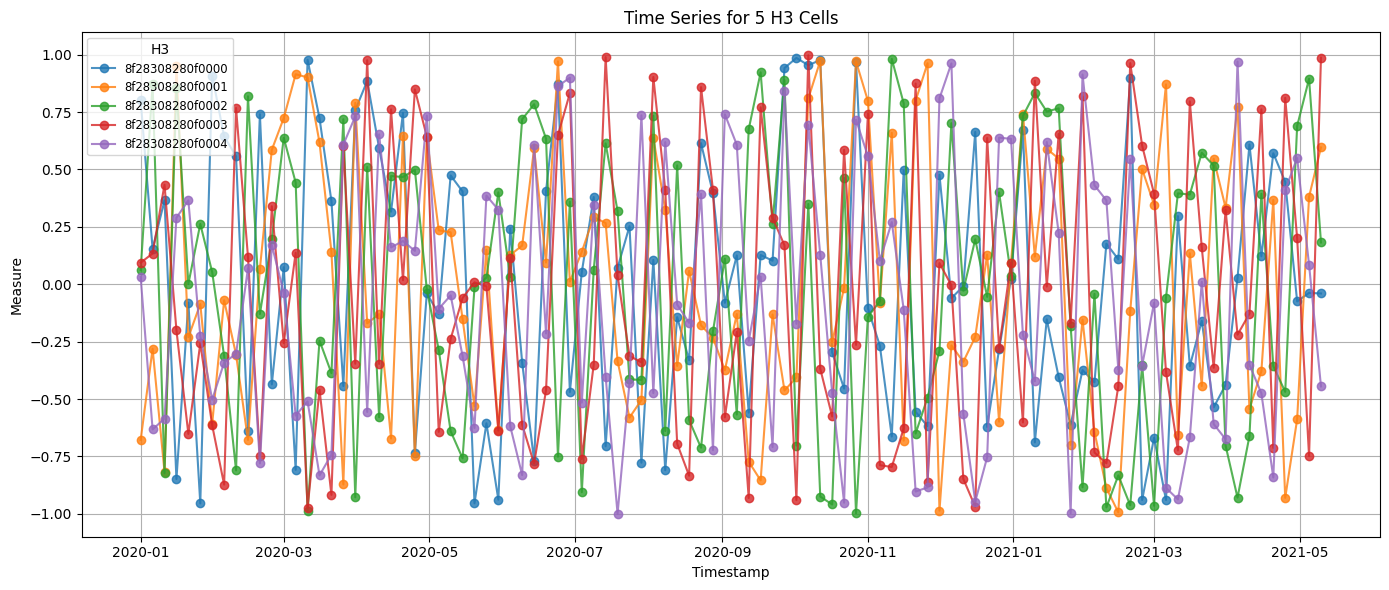

In [18]:
import matplotlib.pyplot as plt

# Select 5 H3s
top5_h3s = pdf['h3'].unique()[:5]
filtered = pdf[pdf['h3'].isin(top5_h3s)].sort_values(['h3', 'timestamp'])

# Plot
plt.figure(figsize=(14, 6))

for h3_id, group in filtered.groupby('h3'):
    plt.plot(group['timestamp'], group['measure'], label=h3_id, marker='o', alpha=0.8)

plt.title("Time Series for 5 H3 Cells")
plt.xlabel("Timestamp")
plt.ylabel("Measure")
plt.legend(title="H3", fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

In [41]:
ndsi_df = (spark.read.format("csv")
               .option("header", "true")
               .option("inferSchema", "true")
               .load("kring2_export.csv"))

In [55]:
ndsi_df.write.saveAsTable("ndsi_data")

In [56]:
ndsi_df = spark.read.table("ndsi_data")

In [54]:
ndsi_df.show(5)

+---------------+------------------+-------------------+
|      timestamp|              cell|            measure|
+---------------+------------------+-------------------+
|20200408T215531|630733541167708159|-0.9983766708045453|
|20200506T220529|630733541166760447|0.22816159372520745|
|20200430T214529|630733541166706175|0.33684473844705276|
|20200504T221541|630733541166767103|   0.52866097493273|
|20200425T214531|630733541166760447| 0.5826945944902759|
+---------------+------------------+-------------------+
only showing top 5 rows



In [44]:
pdf = ndsi_df.toPandas()

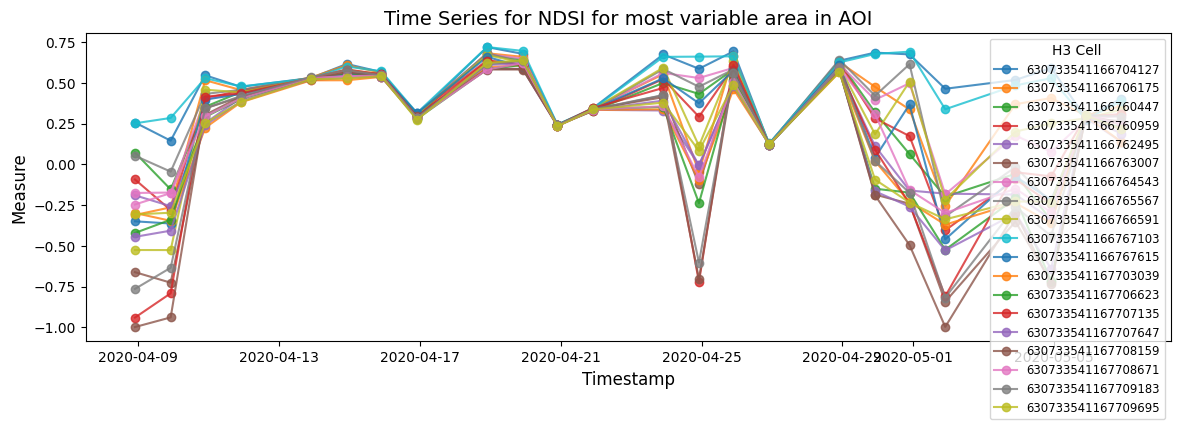

In [58]:
pdf['timestamp'] = pd.to_datetime(pdf['timestamp'])
top5_h3s = pdf['cell'].unique()
filtered = pdf[pdf['cell'].isin(top5_h3s)].sort_values(['cell', 'timestamp'])

fig, ax = plt.subplots(figsize=(14, 4))
for h3_id, group in filtered.groupby('cell'):
    ax.plot(group['timestamp'], group['measure'], label=str(h3_id), marker='o', alpha=0.8)

ax.set_title("Time Series for NDSI for most variable area in AOI", fontsize=14)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Measure", fontsize=12)
ax.legend(title="H3 Cell", fontsize="small")
plt.show()